In [ ]:
#Construct a comprehensive text-to-image generating pipeline that includes GAN-based image generation, text preprocessing, and text embedding creation. This project simulates a real-world use case while integrating all the components.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [2]:
device ="cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on {device}")

Running on cuda


In [3]:
NOISE_DIM=100
TEXT_EMBED_DIM=128
VOCAB_SIZE=1000
SEQ_LEN=5
BATCH_SIZE=64
EPOCHS=40
LR = 1e-4
LAMBDA_GP=10
CRITIC_ITERS=5
IMG_SIZE=64

In [4]:
class TextEncoder(nn.Module):
    def __init__(self, vocab_size,embed_dim):
        super().__init__()
        self.embedding=nn.Embedding(vocab_size,64)
        self.rnn=nn.LSTM(64,embed_dim,batch_first=True)
    def forward(self,text_seq):
        x=self.embedding(text_seq)
        _,(hidden,_)=self.rnn(x)
        return hidden.squeeze(0)

In [5]:
def get_text_batch(labels,batch_size):
    text_seq=labels.view(-1,1).repeat(1,SEQ_LEN)
    return text_seq.to(device)

In [6]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc=nn.Linear(NOISE_DIM+TEXT_EMBED_DIM,512*4*4)
        self.net=nn.Sequential(
            nn.BatchNorm2d(512),
            nn.ConvTranspose2d(512, 256, 4, 2, 1),  
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), 
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),   
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),    
            nn.Tanh()
        )
    def forward(self,z,text_embed):
        x=torch.cat([z,text_embed],dim=1)
        x=self.fc(x).view(-1,512,4,4)
        return self.net(x)

In [7]:
class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.InstanceNorm2d(512),
            nn.LeakyReLU(0.2)
        )
       
        self.conv_dim = 512 * 4 * 4
        self.fc = nn.Linear(self.conv_dim + TEXT_EMBED_DIM, 1)
    
    def forward(self, img, text_embed):
        x = self.conv(img)
        x = x.view(x.size(0), -1)
        x = torch.cat([x, text_embed], dim=1)
        return self.fc(x)

In [8]:
def gradient_penalty(critic, real, fake, text_embed):
    alpha = torch.rand(real.size(0), 1, 1, 1).to(device)
    interpolates = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    d_interpolates = critic(interpolates, text_embed)
    grad = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=torch.ones_like(d_interpolates),
        create_graph=True,
        retain_graph=True
    )[0]
    grad = grad.view(grad.size(0), -1)
    return ((grad.norm(2, dim=1) - 1) ** 2).mean()

In [9]:
text_encoder = TextEncoder(VOCAB_SIZE, TEXT_EMBED_DIM).to(device)
G = Generator().to(device)
C = Critic().to(device)


opt_G = optim.Adam(list(G.parameters()) + list(text_encoder.parameters()), lr=LR, betas=(0.0, 0.9))
opt_C = optim.Adam(C.parameters(), lr=LR, betas=(0.0, 0.9))

In [10]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.Flowers102(root="./data", split="train", download=True, transform=transform)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [11]:
for epoch in range(EPOCHS):
    for batch_idx, (imgs, labels) in enumerate(loader):
        imgs = imgs.to(device)
        labels = labels.to(device)
        curr_batch_size = imgs.size(0)

       
        text_seq = get_text_batch(labels, curr_batch_size)

        text_embed = text_encoder(text_seq)

        for _ in range(CRITIC_ITERS):
            z = torch.randn(curr_batch_size, NOISE_DIM).to(device)
            fake_imgs = G(z, text_embed) 

            gp = gradient_penalty(C, imgs, fake_imgs, text_embed)
            
        
            c_real = C(imgs, text_embed)
            c_fake = C(fake_imgs, text_embed)
            
            c_loss = -(c_real.mean() - c_fake.mean()) + LAMBDA_GP * gp

            opt_C.zero_grad()
            c_loss.backward(retain_graph=True)
            opt_C.step()

        g_loss = -C(fake_imgs, text_embed).mean()

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Critic Loss: {c_loss.item():.4f} | Gen Loss: {g_loss.item():.4f}")

/usr/local/lib/python3.11/dist-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch [1/40] | Critic Loss: -60.2456 | Gen Loss: 41.8757
Epoch [2/40] | Critic Loss: -48.7929 | Gen Loss: 29.7553
Epoch [3/40] | Critic Loss: -41.9061 | Gen Loss: 42.8111
Epoch [4/40] | Critic Loss: -37.9097 | Gen Loss: 38.3290
Epoch [5/40] | Critic Loss: -32.2463 | Gen Loss: 22.9958
Epoch [6/40] | Critic Loss: -25.3633 | Gen Loss: 22.3925
Epoch [7/40] | Critic Loss: -26.0177 | Gen Loss: 27.3667
Epoch [8/40] | Critic Loss: -20.0392 | Gen Loss: 25.1700
Epoch [9/40] | Critic Loss: -18.9461 | Gen Loss: 30.3620
Epoch [10/40] | Critic Loss: -21.0601 | Gen Loss: 30.9573
Epoch [11/40] | Critic Loss: -18.7746 | Gen Loss: 33.0402
Epoch [12/40] | Critic Loss: -20.0218 | Gen Loss: 34.6114
Epoch [13/40] | Critic Loss: -22.5448 | Gen Loss: 43.0664
Epoch [14/40] | Critic Loss: -20.2165 | Gen Loss: 40.1799
Epoch [15/40] | Critic Loss: -22.4001 | Gen Loss: 41.0989
Epoch [16/40] | Critic Loss: -18.2391 | Gen Loss: 33.4862
Epoch [17/40] | Critic Loss: -20.7398 | Gen Loss: 38.0964
Epoch [18/40] | Critic 

In [12]:
test_label = torch.tensor([0]).to(device) 
test_text_seq = get_text_batch(test_label, 1)

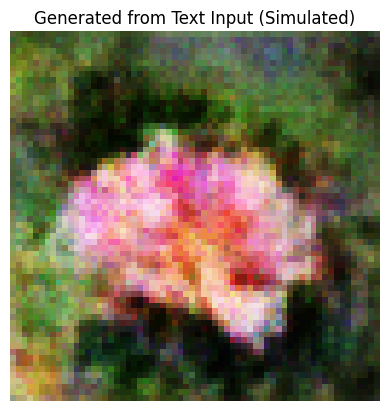

In [13]:
with torch.no_grad():
    
    test_embed = text_encoder(test_text_seq) 
    
    z = torch.randn(1, NOISE_DIM).to(device)
    gen_img = G(z, test_embed).detach().cpu()

plt.imshow((gen_img[0].permute(1,2,0)+1)/2)
plt.title("Generated from Text Input (Simulated)")
plt.axis("off")
plt.show()